In [6]:
# just put your path to the ../ dir
%cd /mnt/c/Users/louis/Documents/GitHub/Low-Dimensionnal-Model-2025

import fct_BoxModel_Gamma as fbm_Gamma

import numpy as np
from scipy.optimize import fsolve, root

import xarray as xr
import pandas as pd
import matplotlib
from matplotlib import cm
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize
import cv2 as cv

from matplotlib import colors

from cmcrameri import cm as cmcra



matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=128):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

lipari_cut = truncate_colormap(cmcra.lipari, minval=0.15, maxval=1.0, n=128)

/mnt/c/Users/louis/Documents/GitHub/Low-Dimensionnal-Model-2025


### Importing the datasets

In [7]:
inputs = xr.open_dataset("model_input_dataset.nc")
index_isf = inputs.Nisf.values
name_isf = inputs.name_isf.values

outputs = xr.open_dataset("model_output_dataset.nc")

q_used = np.array([0.13,0.23,0.19,0.05,0.23,0.12,0.07,0.25,0.17])*1e6 #m^3/s

Gamma_used = 2e-5/q_used #m^-2

### Defining the parameters

In [8]:
# Define reference properties and parameters 

#Ice properties
rho_i = 910 # kg/m^3   (PICO)

#PICO parameters
# Reese 2018
C = 1e6 #m^6/s/kg

gammaT_ref = 2e-5

#Vertical mixing
# ~Olbers & Hellmer 2010
kappa_diff = 1e-7  # m/s
kappa_conv = 1e-3 # m/s

#Polynia
g = 20

# non zero q_conv
r = 0.

### Defining plotting function

In [9]:
# functions to compute the bistable region size

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

def bistable_size(bistable,T_CDW_list,T_CDW_ref,Ap_list):
    idx = find_nearest(T_CDW_list,T_CDW_ref)
    bist_arg = np.where(bistable[:,idx].mask == False)[0]
    Apbmin = Ap_list[bist_arg[0]]
    Apbmax = Ap_list[bist_arg[-1]]
    delta_Ap = Apbmax-Apbmin
    return Apbmin, Apbmax, delta_Ap

In [12]:
def plot_column():

    AABW = False #Include AABW parameterisation ?
    
    Npoint = 100
    
    T_CDW_list = np.linspace(-2.1,2.1,Npoint)
    
    for k, index, name in zip(np.arange(len(index_list)),index_list,name_list):
        print(name)
    
        Ap_ref = np.mean(inputs.Ap.sel(Nisf=index).values)*2/3 # Interannual average, 2/3 factor because only march to october rates here
    
    
        stability_d = np.zeros((Npoint,Npoint))
        stability_c = np.zeros((Npoint,Npoint))
    
        melt_d = np.zeros((Npoint,Npoint))
        melt_c = np.zeros((Npoint,Npoint))
    
        sigma_d = np.zeros((Npoint,Npoint))
        sigma_c = np.zeros((Npoint,Npoint))
        
        nbox = int(inputs.Nbox.sel(Nisf=index).values)
        Ac = inputs.Ac.sel(Nisf=index).values #m^2
    
        xi_ref = np.mean(inputs.xi.sel(Nisf=index).values)/30/24/3600 * 2/3 #m/s : 2/3 factor because only march to october rates here
        y_axis = np.logspace(-1,3,Npoint)
        Ap_list = y_axis/xi_ref/rho_i *1e12/3600/24/365.25
        
        frac = inputs.frac.sel(Nisf=index).values
        depth = inputs.depth.sel(Nisf=index).values
        T_surf_ref = np.mean(inputs.T_surf.sel(Nisf=index).values)
        S_surf_ref = np.mean(inputs.S_surf.sel(Nisf=index).values)
        S_CDW_ref = np.mean(inputs.S_CDW.sel(Nisf=index).values)
    
        Gamma_ref = Gamma_used_list[k]
    
        
        guess_conv_0 = np.array([0,0,35.5,35.5])
        guess_diff_0 = np.array([0,0,35.5,35.5])
        
        for n, T_CDW in enumerate(T_CDW_list):
    
            guess_conv = guess_conv_0
            guess_diff = guess_diff_0
            
            for m, Ap in enumerate(Ap_list):
                    
                
                args = (nbox, C, Gamma_ref, Ac, xi_ref, T_CDW, S_CDW_ref, Ap, kappa_diff, g, frac, depth, r)

                X_d, info, ier, msg = fsolve(fbm_Gamma.BoxModel, guess_diff, args = args, full_output=True,)
                if ier != 1: #management of non convergence cases
                    incr = 0
                    while ier != 1 or X_d[3]<30 or X_d[1]<30:
                        X_d, info, ier, msg = fsolve(fbm_Gamma.BoxModel, np.random.normal(guess_diff,0.15), args = args, full_output=True)
                        incr += 1
                        if incr == 200:
                            print('no conv, diff',m,n)
                            break
                if ier == 1:
                    guess_diff = X_d
                    if m==0:
                        guess_diff_0 = X_d 
    
                if ier==1:
                    sigma_d[m,n] = fbm_Gamma.compute_Sigma(X_d)
                    stability_d[m,n] = fbm_Gamma.compute_Sigma(X_d)<0
                    if stability_d[m,n]:
                        T,S,melt,q = fbm_Gamma.PICO(X_d[1],X_d[3], nbox, C, Gamma_ref, Ac, frac, depth)
                        melt_d[m,n] = fbm_Gamma.compute_m_avg(melt,frac,nbox)
                    else:
                        melt_d[m,n] = np.nan
                else:
                    stability_d[m,n] = np.nan
                    melt_d[m,n] = np.nan
                    
                

                args = (nbox, C, Gamma_ref, Ac, xi_ref, T_CDW, S_CDW_ref, Ap, kappa_conv, g, frac, depth, r)

                X_c, info, ier, msg = fsolve(fbm_Gamma.BoxModel, guess_conv, args = args, full_output=True)
                if ier != 1: #management of non convergence cases
                    incr = 0
                    while ier != 1:
                        X_c, info, ier, msg = fsolve(fbm_Gamma.BoxModel, np.random.normal(guess_conv,0.15), args = args, full_output=True)
                        incr += 1
                        if incr == 200:
                            print('no conv, conv',m,n)
                            break
                if ier==1:
                    guess_conv = X_c
                    if m==0:
                        guess_conv_0 = X_c
                
    
                if ier==1:
                    sigma_c[m,n] = fbm_Gamma.compute_Sigma(X_c)
                    stability_c[m,n] = fbm_Gamma.compute_Sigma(X_c)>0
                    if stability_c[m,n]:
                        T,S,melt,q = fbm_Gamma.PICO(X_c[1],X_c[3], nbox, C, Gamma_ref, Ac, frac, depth)
                        melt_c[m,n] = fbm_Gamma.compute_m_avg(melt,frac,nbox)
                    else:
                        melt_c[m,n] = np.nan
                else:
                    stability_c[m,n] = np.nan
                    melt_c[m,n] = np.nan
    
                
        # show monostable and bistable cases
        stability_map = np.logical_and(stability_c,stability_d)*0 + np.logical_and(stability_c,np.logical_not(stability_d))*(-1) + np.logical_and(np.logical_not(stability_c),stability_d)*1
    
        # show unstable cases 
        stability_map = np.ma.masked_where(np.logical_and(np.logical_not(stability_c),np.logical_not(stability_d)), stability_map)

        # Compute and plot basal mass losses
        melt_c = melt_c*12 *rho_i*Ac /1e12 # Gt/y
        melt_d = melt_d*12 *rho_i*Ac /1e12 # Gt/y
        melt_conv = ax[k].contourf(T_CDW_list, y_axis, melt_c,cmap=lipari_cut,vmin=0,vmax=vmax, levels=levels_d)
        melt_diff = ax[k].contourf(T_CDW_list, y_axis, melt_d,cmap=lipari_cut,vmin=0,vmax=vmax, levels=levels_d) 
        
        # Compute and plot the bistable region
        bistable_zone = np.ma.masked_where(np.logical_not(np.logical_and(stability_c,stability_d)),np.logical_and(stability_c,stability_d)*0.25)
        ax[k].contourf(T_CDW_list, y_axis, bistable_zone,cmap='binary',vmin=0,vmax=1,levels=np.linspace(0,1,6))

        # Plot transition thresholds
        if np.max(sigma_d)>0:
            ax[k].contour(T_CDW_list,y_axis,sigma_d,colors='black',levels=0)
        if np.min(sigma_c)<0:
            ax[k].contour(T_CDW_list,y_axis,sigma_c,colors='black',levels=0,linestyles='dashed')
        
        ax[k].set_title(name)
        ax[k].set_yscale('log')
        ax[k].set_xlim((-2.1,2.1))
        ax[k].set_ylim((1e-1,1e3)) # same y-axis
    
        ax[k].set_ylabel(r'Sea-ice prod. $\Sigma$'+' '+r'$\mathrm{[Gt/y]}$')
        
        if k==kmax:
            ax[k].set_xlabel(r'$T_\mathrm{CDW}$'+' [°C]')

        # Plot the realistic forcings
        T_CDW_series = inputs.T_CDW.sel(Nisf=index).values
        SeaIce_series = inputs.Ap.sel(Nisf=index).groupby('time.year').mean('time').values *rho_i*xi_ref *24*3600*365.25/1e12    *2/3 #2/3 factors to take summer into account
        ax[k].scatter(T_CDW_series,SeaIce_series,marker='+', c='white', zorder=2) 
        ax[k].scatter(np.mean(T_CDW_series),np.mean(SeaIce_series),facecolors='white',edgecolors='black',marker='d',s=50,linewidths=1, zorder=2) #interannual mean
        
        # compute the bistable region size
        Apbmin, Apbmax, delta_Ap = bistable_size(bistable_zone,T_CDW_list,np.mean(T_CDW_series),Ap_list)
        print(delta_Ap*rho_i*xi_ref*24*3600*365.25/1e12,'Gt/y')

        # contour plot the convective basal mass loss
        contour_c = np.ma.masked_where(stability_map !=-1,melt_c)
        cont_c = ax[k].contour(T_CDW_list, y_axis, contour_c, levels_c, colors='whitesmoke', linewidths=1) 
        ax[k].clabel(cont_c, fontsize=8)
    
    # make a colorbar
    cbar_ax = fig.add_axes([0.13, bottom_cbar, 0.75, height_cbar])  # [left, bottom, width, height]
    cbar = fig.colorbar(melt_diff, cax=cbar_ax, orientation='horizontal',
                        label=r'Basal melt $\mathcal{M}$ [Gt/y]') 
    # Move ticks and label to the top
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.xaxis.set_label_position('top')


### Small Cavities

Pine Island
63.911037291193374 Gt/y
Dotson
462.46244737961956 Gt/y
Totten
68.93019677092572 Gt/y
Moscow Univ.
58.99458332148633 Gt/y


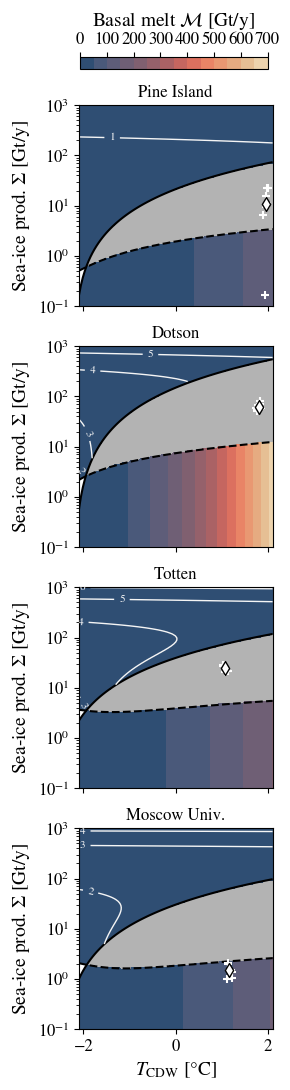

In [23]:
# Warning if computation take to much time, maybe the algotithm can't find some fixed point. Just launch it again because no convergence is tackle with a random walk exploration of the phase space
np.random.seed(0) # this seed works well here

index_list = [66,52,48,33]
name_list = ['Pine Island', 'Dotson', 'Totten', 'Moscow Univ.']
kmax = 4-1
vmax = 750#Gt/y
levels_c = np.arange(0,20,1)
levels_d = np.arange(0,750,50)
height_cbar = 0.01
bottom_cbar = 0.91

Gamma_used_list = [8.69565217e-11,4.00000000e-10,8.00000000e-11,1.17647059e-10] # /^-2

fig, ax = plt.subplots(4,1,figsize=(2.5,12),sharex=True, sharey=True,)

plot_column()

plt.savefig('SI/Figures/FigureS2/FigureS2_small.pdf',format="pdf", bbox_inches = 'tight')
plt.show()

### Medium Cavities

Amery
537.1248485928708 Gt/y
Riiser-Larsen
384.87512137714776 Gt/y
Roi Baudouin
no conv, diff 0 1
no conv, diff 1 1
no conv, diff 0 2
381.8020371131058 Gt/y


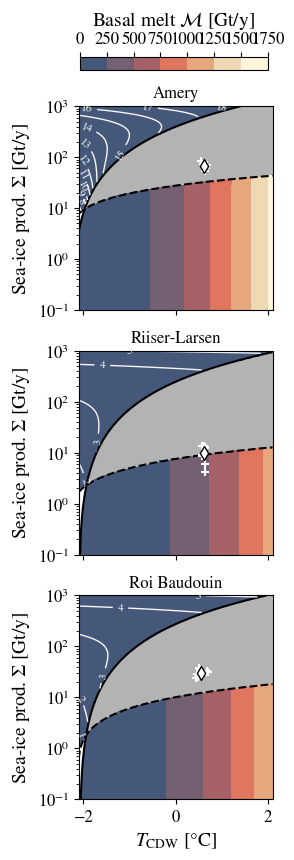

In [18]:
np.random.seed(485445) # this seed works well here

index_list = [31,43,45]
name_list = ['Amery','Riiser-Larsen', 'Roi Baudouin']
kmax = 3-1
vmax = 1500 #Gt/y
levels_c = np.arange(0,20,1)
levels_d = np.arange(0,1751,250)
height_cbar = 0.01*3/2
bottom_cbar = 0.92

Gamma_used_list = [1.05263158e-10,1.66666667e-10,2.85714286e-10] # /^-2

fig, ax = plt.subplots(3,1,figsize=(2.5,9),sharex=True, sharey=True,)

plot_column()

plt.savefig('SI/Figures/FigureS2/FigureS2_medium.pdf',format="pdf", bbox_inches = 'tight')
plt.show()

### Large Cavities

Ross
964.8880826578487 Gt/y
Filchner-Ronne
445.9304855820281 Gt/y


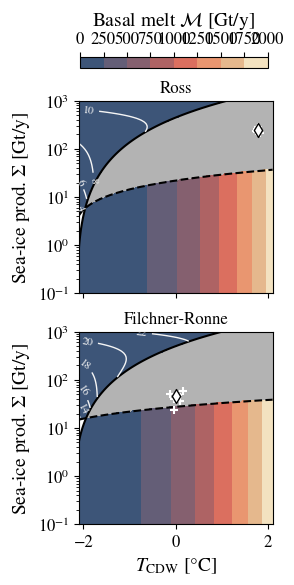

In [19]:
np.random.seed(485445) # this seed works well here

index_list = [10,11]
name_list = ['Ross','Filchner-Ronne']
kmax = 2-1
vmax = 2000 #Gt/y
levels_c = np.arange(0,40,2)
levels_d = np.arange(0,2001,250)
height_cbar = 0.01*2
bottom_cbar = 0.94

Gamma_used_list = [1.53846154e-10, 8.69565217e-11] # /^-2

fig, ax = plt.subplots(2,1,figsize=(2.5,5.5),sharex=True, sharey=True,)
plot_column()

plt.savefig('SI/Figures/FigureS2/FigureS2_large.pdf',format="pdf", bbox_inches = 'tight')
plt.show()